<img src="../notebooks/images/arm_logo.png" width=500 alt="ARM Logo"></img>

# Composite SMPS/CPC Figures

In [15]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LogNorm

plt.rcParams.update({
    'font.family': 'Arial', 'font.size': 16,
    'axes.labelsize': 16, 'axes.titlesize': 18,
    'xtick.labelsize': 16, 'ytick.labelsize': 16,
    'axes.linewidth': 1.5
})

_raw = [
    (37, 70, 159), (58, 90, 170), (78, 111, 183), (104, 144, 199),
    (131, 175, 212), (158, 207, 227), (187, 224, 234), (218, 240, 246),
    (254, 240, 202), (254, 223, 146), (252, 197, 122), (251, 169, 94),
    (245, 134, 78), (237, 98, 58), (221, 78, 46), (210, 58, 46),
]
CUSTOM_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    "custom16", [(r / 255, g / 255, b / 255) for r, g, b in _raw], N=256
)


def plot_smps_local_day(
    data_dir: Path,
    local_date: str,
    utc_offset_hours: int = -6,
    pattern: str = "sgpaossmpsE13.b1.*.nc",
    dp_min: float = 10.7,
    dp_max: float = 532.8,
    vmin: float = 100,
    vmax: float = 100000,
    use_lognorm: bool = True,
    mark_fraction: float | None = None,
) -> None:
    local_start = pd.Timestamp(local_date)
    local_end = local_start + pd.Timedelta(days=1)
    times = []
    spectra = []
    geometric_diameters = []
    diameter = None

    for nc_path in sorted(data_dir.glob(pattern)):
        with xr.open_dataset(nc_path, engine="scipy") as ds:
            local_time = pd.to_datetime(ds["time"].values) + pd.Timedelta(hours=utc_offset_hours)
            keep = (local_time >= local_start) & (local_time < local_end)
            if not keep.any():
                continue

            spec_var = ds["dN_dlogDp"]
            missing = spec_var.attrs.get("missing_value", -9999.0)
            spec = np.asarray(spec_var.values, dtype=float)[keep, :]
            spec[spec == missing] = np.nan

            diameter_values = np.asarray(ds["diameter_mobility"].values, dtype=float)
            size_keep = (diameter_values >= dp_min) & (diameter_values < dp_max)
            spec = spec[:, size_keep]
            geometric_diameter = np.asarray(ds["geometric_mean"].values, dtype=float)[keep]

            if diameter is None:
                diameter = diameter_values[size_keep]
            times.append(pd.DatetimeIndex(local_time[keep]))
            spectra.append(spec)
            geometric_diameters.append(geometric_diameter)

    if not spectra or diameter is None:
        raise ValueError(f"No SMPS data found for local date {local_date}")

    plot_time = times[0].append(times[1:]) if len(times) > 1 else times[0]
    plot_spec = np.vstack(spectra)
    plot_geometric_diameter = np.concatenate(geometric_diameters)
    order = np.argsort(plot_time.values)
    plot_time = plot_time[order]
    plot_spec = plot_spec[order, :]
    plot_geometric_diameter = plot_geometric_diameter[order]

    norm = LogNorm(vmin=vmin, vmax=vmax) if use_lognorm else mpl.colors.Normalize(vmin, vmax)
    fig, ax = plt.subplots(figsize=(11, 3.5))
    pcm = ax.pcolormesh(
        mdates.date2num(plot_time),
        diameter,
        np.where(plot_spec.T > 0, plot_spec.T, np.nan),
        cmap=CUSTOM_CMAP,
        shading="nearest",
        norm=norm,
    )

    finite_geometric = np.isfinite(plot_geometric_diameter)
    ax.plot(
        plot_time[finite_geometric],
        plot_geometric_diameter[finite_geometric],
        linestyle="None",
        marker="o",
        markersize=4,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=0.8,
        zorder=5,
    )

    if mark_fraction is not None:
        threshold = np.nanquantile(plot_geometric_diameter[finite_geometric], mark_fraction)
        mark = finite_geometric & (plot_geometric_diameter <= threshold)
        ax.plot(
            plot_time[mark],
            plot_geometric_diameter[mark],
            linestyle="None",
            marker="o",
            markersize=6,
            markerfacecolor="none",
            markeredgecolor="red",
            markeredgewidth=1.2,
            zorder=6,
        )

    ax.set_yscale("log")
    ax.set_ylabel("Mobility diameter (nm)")
    ax.set_xlabel("Local time (UTC-6)")
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, 3)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
    ax.tick_params(axis="x", which="minor", length=3)

    cbar = fig.colorbar(pcm, ax=ax, pad=0.015, fraction=0.20)
    cbar.set_label("dN/dlogD$_p$ (cm$^{-3}$)")
    title = f"SMPS size distribution, local day {local_date} (UTC-6)"
    if mark_fraction is not None:
        title += f", smallest {int(mark_fraction * 100)}%"
    ax.set_title(title)

    plt.tight_layout()
    plt.show()
    plt.close(fig)


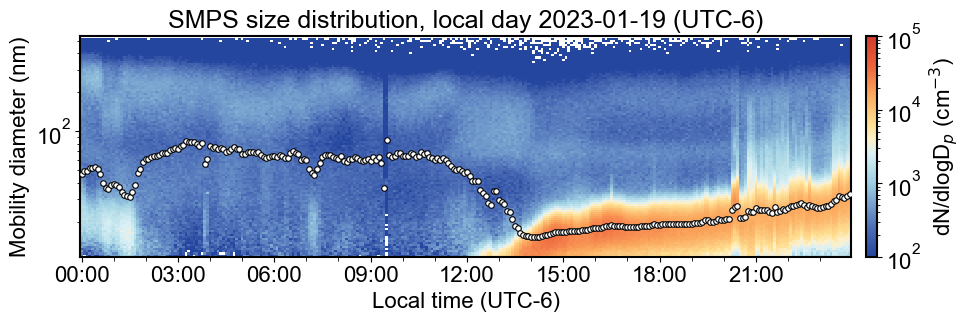

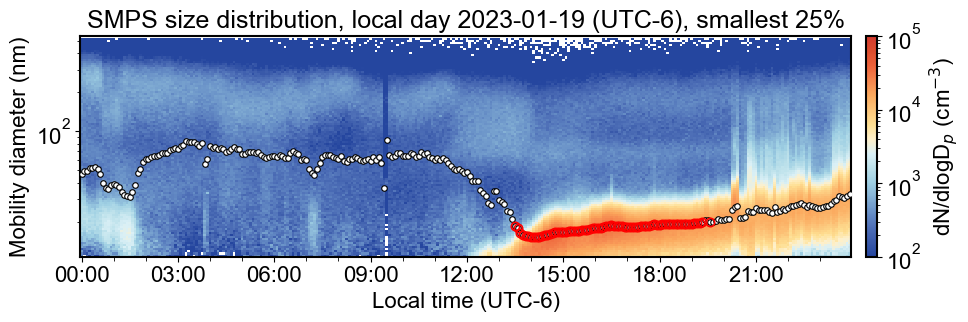

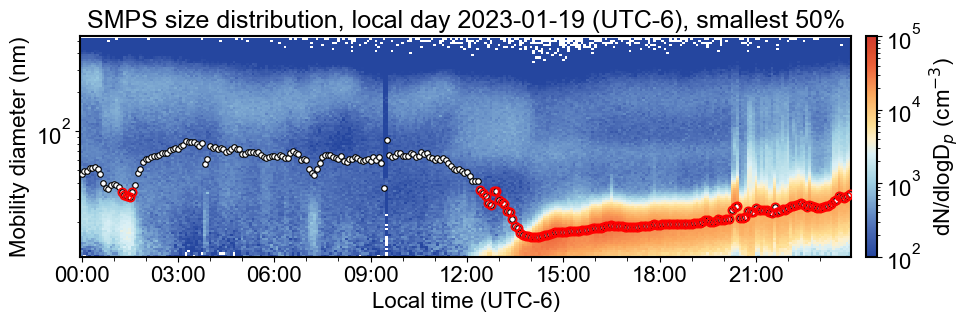

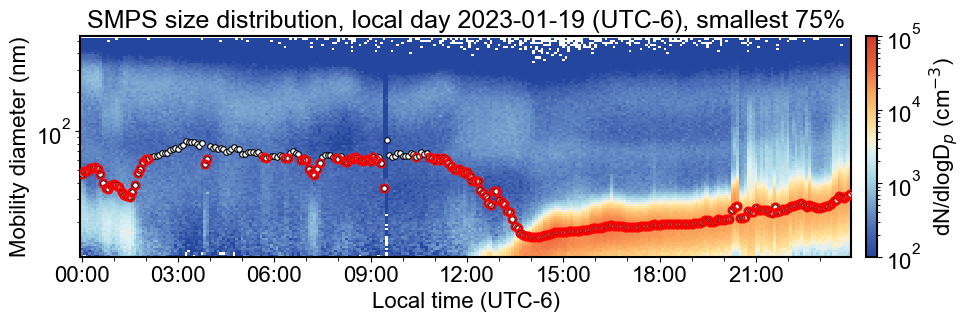

In [16]:
project_root = Path.cwd()
if not (project_root / "data" / "raw" / "smps").exists():
    project_root = project_root.parent

plot_kwargs = dict(
    data_dir=project_root / "data" / "raw" / "smps",
    local_date="2023-01-19",
    utc_offset_hours=-6,
    dp_min=10.7,
    dp_max=532.8,
    vmin=100,
    vmax=100000,
    use_lognorm=True,
)

plot_smps_local_day(**plot_kwargs)

for mark_fraction in [0.25, 0.50, 0.75]:
    plot_smps_local_day(
        **plot_kwargs,
        mark_fraction=mark_fraction,
    )


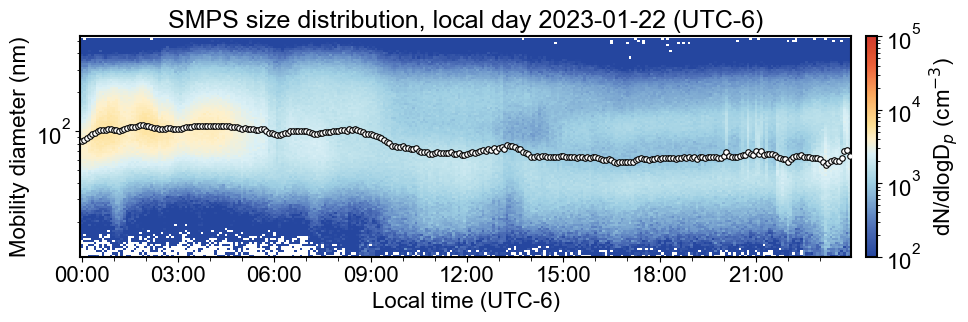

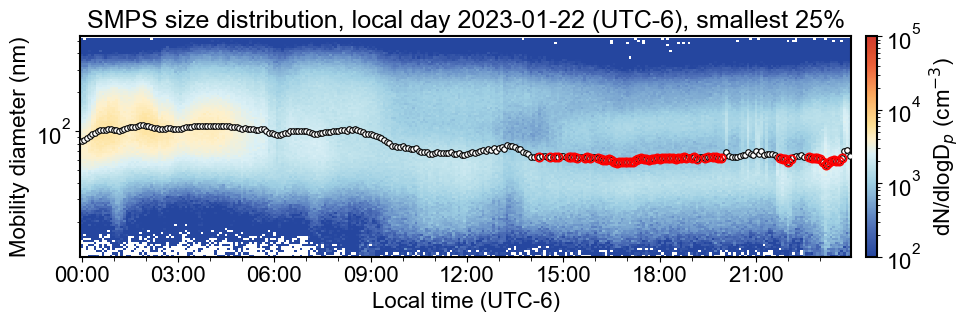

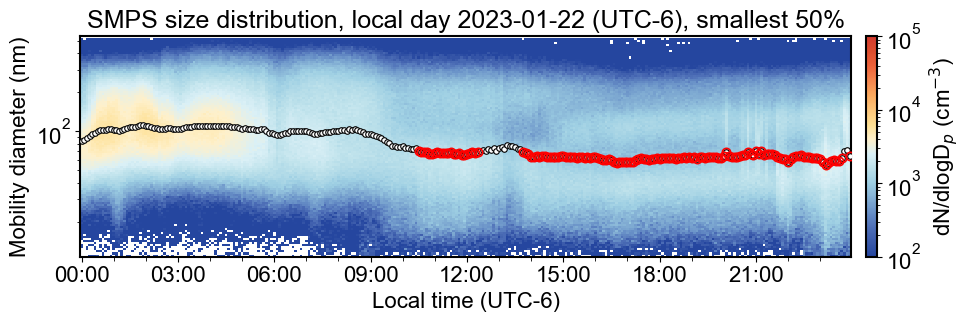

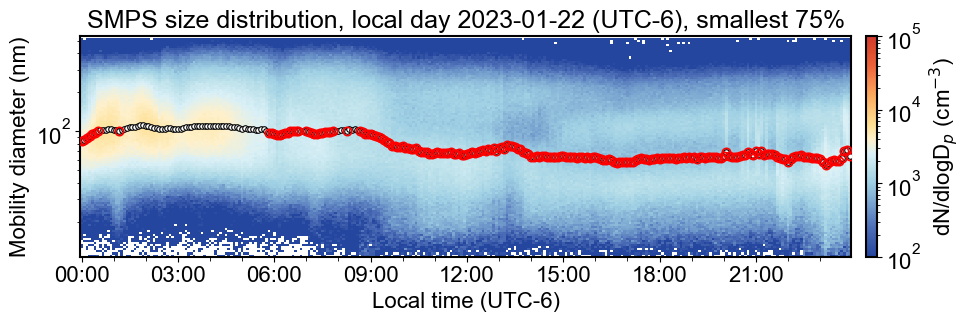

In [17]:
project_root = Path.cwd()
if not (project_root / "data" / "raw" / "smps").exists():
    project_root = project_root.parent

plot_kwargs = dict(
    data_dir=project_root / "data" / "raw" / "smps",
    local_date="2023-01-22",
    utc_offset_hours=-6,
    dp_min=10.7,
    dp_max=532.8,
    vmin=100,
    vmax=100000,
    use_lognorm=True,
)

plot_smps_local_day(**plot_kwargs)

for mark_fraction in [0.25, 0.50, 0.75]:
    plot_smps_local_day(
        **plot_kwargs,
        mark_fraction=mark_fraction,
    )